 ## <center> Least Squares with Neural Network Residual Correction for SECOM Data </center>

<center>林國陽 (Guo-Yang, Lin) </center>

**Computational Environment**

All numerical experiments presented in this Jupyter Notebook were conducted using Python 3.

**AI Usage Statement**

The mathematical formulation, core algorithmic ideas, modeling and experimental decisions, and overall project design were independently developed by the author. ChatGPT was used as an AI-assisted tool for code development, language refinement, the presentation of a limited portion of the mathematical content, and the interpretation of some numerical results. All AI-assisted content was carefully reviewed and verified by the author, who takes full responsibility for the final analysis, conclusions, and results.

### I. Introduction

**Project Objective and Dataset Overview**

This project aims to classify semiconductor products using the SECOM dataset obtained from the UCI Machine Learning Repository (see [9]). The dataset contains 1,567 production samples collected from a semiconductor manufacturing process. Each sample contains 590 numerical measurements collected from sensors and process monitoring points, along with a binary label indicating whether the product passed or failed the quality test. In the original dataset, `-1` represents a passing product and `1` represents a failing product. Only 104 of the 1,567 samples are defective, making this a highly imbalanced classification problem. In addition, the dataset contains missing values, irrelevant measurements, constant features, and potentially correlated sensor variables. Therefore, feature selection is one of the primary concerns of this project after data cleaning.

**Overview of the Proposed WLS–NN Method**

Park et al. [10] applied several established machine-learning methods, including Decision Tree, Random Forest, XGBoost, and SVM, to analyze the SECOM dataset. In comparison, this project investigates an alternative approach based on weighted least squares (WLS) with neural-network (NN) residual correction. A linear support vector machine (SVM) was first used to rank the sensors according to the absolute values of their coefficients, and the 20 highest-ranked sensors were retained for subsequent modeling. WLS was then used to construct a linear baseline, while a small neural network was trained to predict the residuals between the actual labels and the WLS scores. The final hybrid score was obtained by adding the predicted residual correction to the original WLS score.

**Effectiveness of Neural-Network Residual Correction**

On the test set used in this experiment, the standalone WLS model correctly classified 259 of the 293 passing products and detected 11 of the 21 defective products, achieving a balanced accuracy of $0.7039$. After applying the neural-network residual correction, the hybrid model correctly classified 274 passing products and detected 13 defective products, increasing the balanced accuracy to $0.7771$. Compared with WLS alone, the hybrid model correctly retained 15 additional passing products and detected two additional defective products. Its passing-product recall, defective-product recall, defective-product precision, and defective-product F1 score were $0.9352$, $0.6190$, $0.4063$, and $0.4906$, respectively.

These results indicate that the small residual neural network learned useful information that was not represented by the original WLS model and successfully corrected part of its prediction error. More generally, the universal approximation theorem established by Cybenko [7] suggests that a neural network has the theoretical capacity to approximate the residual errors left by a wide range of existing baseline algorithms. Therefore, neural-network residual correction is not conceptually limited to WLS and may provide a general framework for improving other baseline models. However, this theorem describes approximation capability rather than guaranteeing successful training or improved generalization in every application.

**Comparison with Published Results**

The proposed method also produced competitive numerical results compared with the SVM approach reported by Park et al. [10]. Their selected SVM model achieved an accuracy of $0.8514$, a balanced accuracy of approximately $0.7405$, a geometric mean of $0.7295$, and a defective-product recall of approximately $0.6129$. In comparison, the proposed WLS–NN model achieved an accuracy of $0.9140$, a balanced accuracy of $0.7771$, a geometric mean of $0.7609$, and a defective-product recall of $0.6190$. The proposed hybrid model therefore achieved numerically higher values for all four metrics. These results demonstrate that the proposed WLS–NN framework is competitive with previously published machine-learning results for the SECOM dataset. (**Note:** The two studies used different data partitions and model-selection procedures. Therefore, this comparison should be interpreted as evidence of competitive performance rather than a strictly controlled demonstration that the proposed method outperforms the approach of Park et al. [10].)

**Outline**

The remainder of this project is organized as follows. Section 2 describes the data preprocessing procedure. Section 3 introduces the mathematical background of the support vector machine (SVM) and applies a linear SVM to rank and select relevant sensor measurements. Section 4 presents the main proposed method, including the weighted least-squares baseline and the neural-network residual correction. Finally, Section 5 summarizes the principal results, compares them with previously published findings, discusses the limitations of the present experiment, and suggests directions for future work.

### II. Data Preprocessing

In this section, several basic preprocessing steps are applied to the original dataset. The resulting processed data are then used as the input for the feature-selection and classification algorithms introduced in the subsequent sections.

#### II.1 Constructing the  Dataframe

In [1]:
import numpy as np
import pandas as pd
import sys
import sklearn

In [2]:
secom_data = pd.read_csv("secom.data", sep="\s+", header=None)
secom_data

,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,2899.41,2464.36,2179.7333,3085.3781,1.4843,100.0,82.2467,0.1248,1.3424,-0.0045,...,0.0047,203.1720,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720
1563,3052.31,2522.55,2198.5667,1124.6595,0.8763,100.0,98.4689,0.1205,1.4333,-0.0061,...,NaN,NaN,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720
1564,2978.81,2379.78,2206.3000,1110.4967,0.8236,100.0,99.4122,0.1208,NaN,NaN,...,0.0025,43.5231,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231
1565,2894.92,2532.01,2177.0333,1183.7287,1.5726,100.0,98.7978,0.1213,1.4622,-0.0072,...,0.0075,93.4941,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941


In [3]:
labels_data = pd.read_csv("secom_labels.data", sep="\s+", header=None)
labels_data

,0,1
0,-1,19/07/2008 11:55:00
1,-1,19/07/2008 12:32:00
2,1,19/07/2008 13:17:00
3,-1,19/07/2008 14:43:00
4,-1,19/07/2008 15:22:00
...,...,...
1562,-1,16/10/2008 15:13:00
1563,-1,16/10/2008 20:49:00
1564,-1,17/10/2008 05:26:00
1565,-1,17/10/2008 06:01:00


In [4]:
labels_data.iloc[:, [0]].value_counts()

0 
-1    1463
 1     104
Name: count, dtype: int64

In [5]:
labels = labels_data.iloc[:, [0]]
labels.iloc[:, 0] = labels.iloc[:, 0].replace(-1, 0)
labels

,0
0,0
1,0
2,1
3,0
4,0
...,...
1562,0
1563,0
1564,0
1565,0


Because the objective is binary classification rather than exact label reconstruction, the original labels were recoded from `{-1, 1}` to `{0, 1}`. Under this encoding, most entries of the label vector are zero because passing products form the majority class. This produces a sparse target vector and allows the output of the weighted least-squares model to be interpreted as a continuous defect score.

In [6]:
labels.value_counts()

0
0    1463
1     104
Name: count, dtype: int64

In [7]:
raw_data = pd.concat([secom_data, labels], axis=1)
raw_data              

,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,0
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,0
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,0
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,0
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,2899.41,2464.36,2179.7333,3085.3781,1.4843,100.0,82.2467,0.1248,1.3424,-0.0045,...,203.1720,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720,0
1563,3052.31,2522.55,2198.5667,1124.6595,0.8763,100.0,98.4689,0.1205,1.4333,-0.0061,...,NaN,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720,0
1564,2978.81,2379.78,2206.3000,1110.4967,0.8236,100.0,99.4122,0.1208,NaN,NaN,...,43.5231,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231,0
1565,2894.92,2532.01,2177.0333,1183.7287,1.5726,100.0,98.7978,0.1213,1.4622,-0.0072,...,93.4941,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941,0


In [8]:
raw_data.columns = [*[f"sensor_{i}" for i in range(1, 591)],"label"]
raw_data

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589,sensor_590,label
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,0
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,0
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,0
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,2899.41,2464.36,2179.7333,3085.3781,1.4843,100.0,82.2467,0.1248,1.3424,-0.0045,...,203.1720,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720,0
1563,3052.31,2522.55,2198.5667,1124.6595,0.8763,100.0,98.4689,0.1205,1.4333,-0.0061,...,NaN,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720,0
1564,2978.81,2379.78,2206.3000,1110.4967,0.8236,100.0,99.4122,0.1208,NaN,NaN,...,43.5231,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231,0
1565,2894.92,2532.01,2177.0333,1183.7287,1.5726,100.0,98.7978,0.1213,1.4622,-0.0072,...,93.4941,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941,0


The Dataframe `raw_data` now contains both the sensor measurements and their corresponding labels. Next, the missing values in `raw_data` are processed.

#### II.2 Handling Missing Values

In [9]:
missing_summary = pd.DataFrame({"missing_count": raw_data.isna().sum(), 
                                "missing_percentage": raw_data.isna().mean() * 100
                               }).sort_values("missing_count", ascending=False)

pd.set_option('display.max_rows', None)
print(missing_summary)

            missing_count  missing_percentage
sensor_293           1429           91.193363
sensor_294           1429           91.193363
sensor_158           1429           91.193363
sensor_159           1429           91.193363
sensor_221           1341           85.577537
sensor_359           1341           85.577537
sensor_86            1341           85.577537
sensor_493           1341           85.577537
sensor_383           1018           64.964901
sensor_385           1018           64.964901
sensor_245           1018           64.964901
sensor_112           1018           64.964901
sensor_517           1018           64.964901
sensor_518           1018           64.964901
sensor_111           1018           64.964901
sensor_247           1018           64.964901
sensor_246           1018           64.964901
sensor_384           1018           64.964901
sensor_110           1018           64.964901
sensor_519           1018           64.964901
sensor_579            949         

In [10]:
# 1. Calculate the percentage of missing values in each column
missing_percentage = raw_data.isna().mean() * 100

# 2. Identify columns with more than 45% missing values
columns_to_drop = missing_percentage[missing_percentage > 45].index

# 3. Remove these columns
processed_data = raw_data.drop(columns=columns_to_drop).copy()

# 4. Fill the remaining missing values with the median of each column
data = processed_data.fillna(processed_data.median())

print("Number of columns removed:", len(columns_to_drop))
print("Number of remaining missing values:", data.isna().sum().sum())
print("Shape of the processed data:", data.shape)

Number of columns removed: 32
Number of remaining missing values: 0
Shape of the processed data: (1567, 559)


A total of 32 columns contain more than 45% missing values; therefore, these columns were removed. Among the remaining columns, the proportion of missing observations does not exceed 18%. The remaining missing values were replaced with the median of their corresponding columns. After preprocessing, the resulting dataframe has a size of $1567 \times 559$, consisting of 558 sensor columns and one label column.

#### II.3 Rank of the Data Matrix

Number of singular values: 558

Singular values:
     index  singular_value
0        1    2.000748e+02
1        2    1.636456e+02
2        3    1.444766e+02
3        4    1.366368e+02
4        5    1.238077e+02
5        6    1.205389e+02
6        7    1.160693e+02
7        8    1.148960e+02
8        9    1.086373e+02
9       10    1.036090e+02
10      11    9.897638e+01
11      12    9.805374e+01
12      13    9.666074e+01
13      14    9.632649e+01
14      15    9.376385e+01
15      16    9.172981e+01
16      17    9.107938e+01
17      18    8.991477e+01
18      19    8.796218e+01
19      20    8.667308e+01
20      21    8.606756e+01
21      22    8.492797e+01
22      23    8.366815e+01
23      24    8.329568e+01
24      25    8.261403e+01
25      26    8.210390e+01
26      27    7.967746e+01
27      28    7.944563e+01
28      29    7.851513e+01
29      30    7.758630e+01
30      31    7.745355e+01
31      32    7.612666e+01
32      33    7.558889e+01
33      34    7.458508e+01
34    

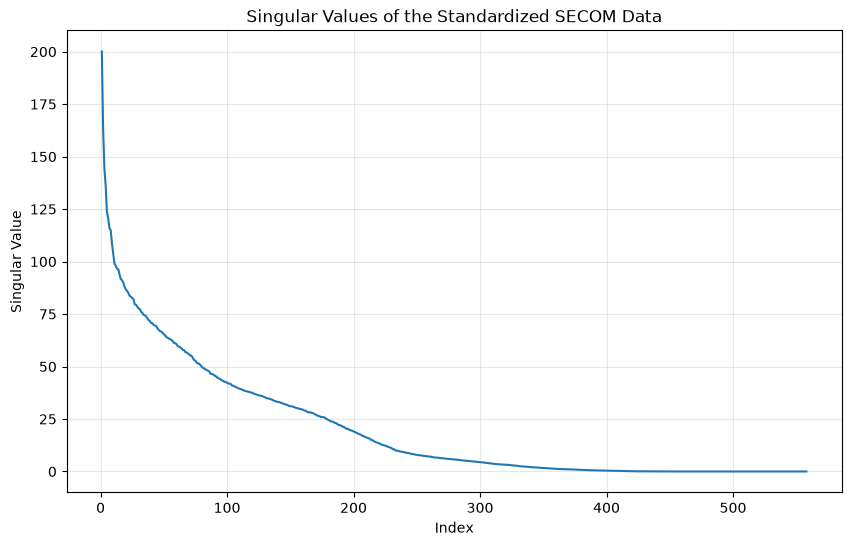

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

# ============================================================
# 1. Remove the label column
# ============================================================

X = data.drop(columns="label")

# ============================================================
# 2. Standardize the sensor features
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# 3. Compute singular values
# ============================================================

singular_values = np.linalg.svd(
    X_scaled,
    compute_uv=False
)

# Store singular values in a DataFrame
singular_value_table = pd.DataFrame({
    "index": np.arange(
        1,
        len(singular_values) + 1
    ),
    "singular_value": singular_values
})

pd.set_option("display.max_rows", None)

print("Number of singular values:", len(singular_values))
print("\nSingular values:")
print(singular_value_table)

# ============================================================
# 4. Plot the singular values
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    singular_value_table["index"],
    singular_value_table["singular_value"]
)

plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.title("Singular Values of the Standardized SECOM Data")
plt.grid(alpha=0.3)
plt.show()

We perform singular value decomposition (SVD) to estimate the rank of the data matrix after excluding the label column. The results show a substantial gap between the 437th and 438th singular values, whose magnitudes are approximately $10^{-4}$ and $10^{-14}$, respectively. This gap indicates that the numerical rank of the data matrix is approximately 437.

The numerical rank suggests that a subset of 437 approximately linearly independent sensor columns can span the column space of the data matrix. Consequently, the remaining 121 sensor columns can be approximately represented as linear combinations of these 437 columns. However, SVD alone does not identify which 437 original sensor columns should be selected.

### III. Support Vector Machine (SVM)

Before applying the least-squares procedure, feature selection is performed. In this project, a linear SVM is trained on the standardized training data, and the sensors are ranked according to the absolute values of the resulting SVM coefficients. Sensors with larger absolute coefficients are regarded as more influential.

The first subsection, Section III.1, introduces the mathematical background of support vector machines, beginning with the linear hard-margin SVM, followed by the soft-margin SVM, and finally the kernel SVM. Readers may skip this subsection if desired. Section III.2 presents the numerical implementation of the linear SVM and discusses the corresponding results. In addition to evaluating the classification performance of the linear SVM, we use the absolute values of its coefficients to rank the sensors and retain the top 60 features. Subsets of these selected sensors are then used to construct the feature spaces for the subsequent weighted least-squares model and the neural-network-aided least-squares method.

#### III.1 Mathematical Background

**Linear SVM: Hard Margin**

The set $\{(x_i, y_i)\}_{i=1}^{n}$ consists of $n$ training data points, where $x_i$ denotes the input feature vector and $y_i \in \{-1, 1\}$ denotes its corresponding class label.

Suppose there exists a vector $w$ and a real value $b$ such that 

$$
\begin{cases}
w^T x_i + b \ge 1, & \text{if } y_i = 1, \\
w^T x_i + b \le -1, & \text{if } y_i = -1. \tag{1}
\end{cases}
$$

This means that the two hyperplanes separate the training data without any classification errors. Equivalently, the two inequalities above can be written as a single compact constraint:

$$
y_i(w^T x_i + b) \ge 1, \quad i = 1, \ldots, n \tag{2}.
$$

The distance between the two hyperplanes $w^T x + b = 1$ and $w^T x + b = -1$ is called the *margin*. By high school mathematics, the margin is $\frac{2}{\|w\|}.$ Our goal is to maximize the margin under constraint (2). That is,

$$
\max_{w,b} \frac{2}{\|w\|}
\quad \text{subject to} \quad
y_i(w^T x_i + b) \ge 1,\quad i = 1, \ldots, n. \tag{3}
$$

And it is equivalent to solve the following minimization problem:

$$
\min_{w,b} \frac{1}{2} \|w\|^2
\quad \text{subject to} \quad
y_i(w^T x_i + b) \ge 1,\quad i = 1, \ldots, n.
\tag{4}
$$

Denote $f(w,b)=\frac{1}{2}\|w\|^2$ and $g_i(w,b)=y_i(w^T x_i+b)-1$. The Lagrange multiplier method gives 
$$
\nabla f = \sum_{i=1}^{n}\lambda_i \nabla g_i \tag{5}.
$$

Moreover, $\lambda_i \ne 0$ only for training points $x_i$ satisfying $y_i(w^T x_i+b)=1$, and these points are called *support vectors*. The above equation can be written as

$$
\begin{bmatrix}
w \\
0
\end{bmatrix}
=
\begin{bmatrix}
\sum_{i=1}^{n} \lambda_i y_i x_i \\
\sum_{i=1}^{n} \lambda_i y_i
\end{bmatrix}.
\tag{6}
$$

Then we have $ \|w\|^2 = \sum_{i=1}^{n} \lambda_i$ in this case.

To solve the multipliers $\lambda_i$ rigorously, the Lagrangian formulation of the optimization problem (4) is usually reformulated as a quadratic programming problem. We omit the details here and refer the reader to Cortes and Vapnik [1].

**Linear SVM: Soft Margin**

However, in practical applications, we do not generally expect the training data to be perfectly separable by a hyperplane. We therefore turn to the so-called *soft-margin* setting, in which classification errors and margin violations are permitted but penalized through an additional term in the minimization problem. In our implementation, `LinearSVC` uses the squared hinge loss by default. Therefore, we define

$$
\xi_i = \left(\max\{0, 1-y_i(w^T x_i + b)\}\right)^2,
\quad i = 1, \ldots, n.
\tag{7}
$$

Then we shift our attention from the hard-margin optimization problem (4) to the following soft-margin problem:

$$
\min_{w,b} \frac{1}{2}\|w\|^2 + C \sum_{i=1}^{n} \xi_i,
\tag{8}
$$

where $C$ is a positive constant specified by the user.

Recall that $f(w,b)=\frac{1}{2}\|w\|^2$ and $g_i(w,b)=y_i(w^Tx_i+b)-1$. Assume that $(w_0,b_0)$ is the solution to the optimization problem in (8). Direct differentiation gives

$$
w_0
=
\sum_{i:\, y_i(w_0^T x_i+b_0) < 1}
-2C g_i(w_0,b_0)y_i x_i.
\tag{9}
$$

This means that $w_0$ can be written as a linear combination of the training vectors that are classified incorrectly (cf. Cortes and Vapnik [1]). For convenience, define

$$
\alpha_i =
\begin{cases}
-2C g_i(w_0,b_0), & \text{if } y_i(w_0^Tx_i+b_0)<1, \\
0, & \text{otherwise}. \tag{10}
\end{cases}
$$

Then equation (9) can be written as

$$
w_0
=
\sum_{i=1}^{n}
\alpha_i y_i x_i.
\tag{11}
$$

Note that since $C>0$ and $g_i(w_0,b_0)<0$ for each $i$ satisfying $y_i(w_0^Tx_i+b_0)<1$, we have $\alpha_i \ge 0$.

**Kernel SVM**

Assume that each training data point satisfies $x_i \in \mathbb{R}^m$, and consider a nonlinear map $\phi:\mathbb{R}^m \to \mathbb{R}^k$. Then the labeled training data becomes $\{(\phi(x_i), y_i)\}_{i=1}^{n}$. The goal of introducing the nonlinear map $\phi$ is to make the training data more separable in the feature space. Assume that the classifier vector $w_0$ and bias $b_0$ separate the training data best in the feature space. Specifically, let

$$
h_j = y_j\left(w_0^T\phi(x_j)+b_0\right),
\quad j=1,\ldots,n. \tag{12}
$$

Then $w_0$ and $b_0$ are chosen to maximize the number of indices $j$ such that $h_j \ge 1$.

By the equation (11), $w_0$ is a linear combination of the training data in the feature space:

$$
w_0
=
\sum_{i=1}^{n}
\alpha_i y_i \phi(x_i).
\tag{13}
$$

Substituting the equation (13) into equation (12), for each $j=1,\ldots,n$, we obtain

$$
\begin{aligned}
h_j
&=
\sum_{i=1}^{n}
\alpha_i y_i y_j \phi(x_i)^T \phi(x_j)
+
y_j b_0 \\[4pt]
&=
\alpha_j \|\phi(x_j)\|^2
+ \sum_{i:\, y_i = y_j,\; i\ne j}
\alpha_i \phi(x_i)^T \phi(x_j)
-
\sum_{i:\, y_i \ne y_j}
\alpha_i \phi(x_i)^T \phi(x_j)
+
y_j b_0.
\end{aligned}
\tag{14}
$$

From the equation (14), we can see that $h_j$ becomes larger when $\phi(x_j)$ has a large inner product with training vectors from the same class and a small inner product with training vectors from the opposite class. Therefore, an effective feature mapping $\phi$ should make samples from the same class more similar in the feature space, while making samples from different classes less similar.

Let $\Omega \subseteq \mathbb{R}^m$ s.t. $L^2(\Omega)$ be a separable Hilbert space. Let $K \in L^2(\Omega \times \Omega)$ be symmetric. Assume that the function $K$ satisfies the Mercer's condition (see [1] and [5]). For any $f \in L^2(\Omega)$, define a new function $\hat{f}$ by

$$
\hat{f}(v)
=
\int_{\Omega} K(u,v) f(u)\,du,
\quad \forall v\in\Omega.
\tag{15}
$$

Then $\hat{f}$ is also a function in $L^2(\Omega)$. Define the function $T$ by $T(f) = \hat{f}$ for all $f \in L^2(\Omega)$. Then $T$ is a linear operator on $L^2(\Omega)$, denoted by $T \in \mathcal{L}(L^2(\Omega))$. And $T$ is self-adjoint. In fact, $T$ is a Hilbert-Schmidt operator, and hence it is compact (see Rosenzweig [4]). By the Hilbert-Schmidt theorem (see Royden and Fitzpatrick [3]), there exists an orthonormal basis $\{\psi_i\}_{i=1}^{\infty}$ of the separable Hilbert space $L^2(\Omega)$ s.t. $T(\psi_i) = \lambda_i \psi_i$ for each $i \in \mathbb{N}$, where $\lim_{i\to\infty}\lambda_i=0$. Then one can show that 

$$
K(u,v)
=
\sum_{i=1}^{\infty}
\lambda_i \psi_i(u)\psi_i(v),
\quad (u,v)\in\Omega\times\Omega.
\tag{16}
$$

Mercer's condition ensures that $\lambda_i \ge 0$ for all $i$. Take $\phi(z)=\left(\sqrt{\lambda_1}\psi_1(z),\sqrt{\lambda_2}\psi_2(z),\ldots\right)$ for all $z \in \Omega$. Then we have

$$
K(u,v) = \phi(u)^T \phi(v),
\quad (u,v)\in\Omega\times\Omega.
\tag{17}
$$

Substituting the equation (17) into equation (14), we have
$$
h_j
=
\sum_{i=1}^{n}
\alpha_i y_i y_j K(x_i,x_j)
+
y_j b_0,
\quad j=1,\ldots,n.
\tag{18}
$$

And the classification function $h$ for an unknown vector $x$ can be written as

$$
\begin{aligned}
h(x) =
w_0^T\phi(x)+b_0 =
\sum_{i=1}^{n}\alpha_i y_i \phi(x_i)^T\phi(x)+b_0 =
\sum_{i=1}^{n}\alpha_i y_i K(x_i,x)+b_0.
\end{aligned}
\tag{19}
$$

From equation (19), we can see that the problem is transformed from explicitly determining the nonlinear map $\phi$ to choosing a suitable kernel function $K$. Thus, we no longer need to compute $\phi$ explicitly. Instead, we use a valid kernel $K$, which is symmetric, belongs to $L^2$, and satisfies Mercer's condition. Under these assumptions, $K$ can be interpreted as an inner product in the feature space, allowing SVM to separate the data nonlinearly.

Commonly used kernel functions include the *linear kernel, polynomial kernel, radial basis function kernel*, and *sigmoid kernel* (see [6]). The linear kernel is defined by $K(x,z)=x^Tz.$ This kernel corresponds to the original linear SVM. It does not introduce nonlinear features.

The polynomial kernel is defined by

$$
K(x,z)=(\gamma x^Tz+r)^d, \tag{20}
$$

where $d$ is the degree of the polynomial, $\gamma>0$ controls the scale of the inner product. This kernel allows the model to capture polynomial interactions among features.

The radial basis function kernel, also called the *RBF kernel* or *Gaussian kernel*, is defined by

$$
K(x,z)=\exp(-\gamma\|x-z\|^2), \tag{21}
$$

where $\gamma>0$ controls how fast the similarity decreases as the distance between $x$ and $z$ increases. The RBF kernel is one of the most commonly used kernels because it can model complex nonlinear relationships.

The sigmoid kernel is defined by

$$
K(x,z)=\tanh(\gamma x^Tz+r). \tag{22}
$$

It is related to the activation function used in neural networks. However, it is less commonly used in practice than the RBF kernel, because it does not always satisfy the conditions of a valid Mercer kernel for all parameter choices.

#### III.2 Numerical Experiment of Linear SVM

The purpose of this soft-margin linear SVM numerical experiment is to rank the sensors according to the absolute values of their coefficients and select the top 60 sensors that contribute most strongly to the learned linear decision function.

In [12]:
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.exceptions import ConvergenceWarning


# ============================================================
# 0. Basic settings
# ============================================================

RANDOM_STATE = 42
NUMBER_OF_SELECTED_SENSORS = 60


# ============================================================
# 1. Prepare the sensor data and labels
# ============================================================

X = data.drop(columns="label").copy()

# Support both {-1, 1} and {0, 1} label formats
label_values = set(data["label"].dropna().unique())

if label_values == {-1, 1}:
    y = data["label"].map({-1: 0, 1: 1}).astype(int)
elif label_values == {0, 1}:
    y = data["label"].astype(int)
else:
    raise ValueError(f"Unexpected label values: {label_values}")

if X.isna().any().any():
    raise ValueError("The sensor data still contain missing values.")


# ============================================================
# 2. Split the data into training and test sets
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

print("\nTraining label distribution:")
print(y_train.value_counts().sort_index())

print("\nTest label distribution:")
print(y_test.value_counts().sort_index())


# ============================================================
# 3. Standardize all sensors using the training set
# ============================================================

svm_scaler = StandardScaler()

X_train_scaled = svm_scaler.fit_transform(X_train)
X_test_scaled = svm_scaler.transform(X_test)


# ============================================================
# 4. Train a soft-margin linear SVM using all sensors
# ============================================================

linear_svm = LinearSVC(
    C=1.0,
    loss="squared_hinge",
    class_weight="balanced",
    dual=False,
    max_iter=300000,
    random_state=RANDOM_STATE
)

svm_converged = True
svm_warning = ""

with warnings.catch_warnings(record=True) as warning_list:
    warnings.simplefilter("always", ConvergenceWarning)
    linear_svm.fit(X_train_scaled, y_train)

    for warning in warning_list:
        if issubclass(warning.category, ConvergenceWarning):
            svm_converged = False
            svm_warning = str(warning.message)
            break

print("\nLinear SVM converged:", svm_converged)

if not svm_converged:
    print("Convergence warning:", svm_warning)


# ============================================================
# 5. Evaluate the linear SVM
#
# LinearSVC uses zero as its default decision threshold.
# ============================================================

y_train_pred = linear_svm.predict(X_train_scaled)
y_test_pred = linear_svm.predict(X_test_scaled)

print("\nTraining accuracy:")
print(accuracy_score(y_train, y_train_pred))

print("\nTraining balanced accuracy:")
print(balanced_accuracy_score(y_train, y_train_pred))

print("\nTraining confusion matrix:")
print(confusion_matrix(y_train, y_train_pred, labels=[0, 1]))

print("\nTest accuracy:")
print(accuracy_score(y_test, y_test_pred))

print("\nTest balanced accuracy:")
print(balanced_accuracy_score(y_test, y_test_pred))

print("\nTest confusion matrix:")
print(confusion_matrix(y_test, y_test_pred, labels=[0, 1]))

print("\nTest classification report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        labels=[0, 1],
        target_names=["Pass (0)", "Fail (1)"],
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 6. Rank all sensors by the absolute SVM coefficient
# ============================================================

sensor_ranking = pd.DataFrame({
    "sensor": X_train.columns,
    "coefficient": linear_svm.coef_[0],
    "absolute_coefficient": np.abs(linear_svm.coef_[0])
})

sensor_ranking = sensor_ranking.sort_values(
    by="absolute_coefficient",
    ascending=False
).reset_index(drop=True)


# ============================================================
# 7. Store the 60 highest-ranked sensors for least squares
# ============================================================

top_60_sensor_weights = sensor_ranking.head(
    NUMBER_OF_SELECTED_SENSORS
).copy()

top_60_sensors = top_60_sensor_weights["sensor"].tolist()

print("\nTop 60 sensor weights:")
print(top_60_sensor_weights)

print("\nTop 60 sensors in descending order:")
print(top_60_sensors)


# ============================================================
# 8. Store objects for the subsequent least-squares procedure
# ============================================================

selected_sensors = top_60_sensors
selected_sensor_weights = top_60_sensor_weights
feature_ranking = sensor_ranking
feature_selection_model = linear_svm
feature_selection_scaler = svm_scaler

Training data shape: (1253, 558)
Test data shape: (314, 558)

Training label distribution:
label
0    1170
1      83
Name: count, dtype: int64

Test label distribution:
label
0    293
1     21
Name: count, dtype: int64

Linear SVM converged: True

Training accuracy:
1.0

Training balanced accuracy:
1.0

Training confusion matrix:
[[1170    0]
 [   0   83]]

Test accuracy:
0.8407643312101911

Test balanced accuracy:
0.5389241020640338

Test confusion matrix:
[[260  33]
 [ 17   4]]

Test classification report:
              precision    recall  f1-score   support

    Pass (0)     0.9386    0.8874    0.9123       293
    Fail (1)     0.1081    0.1905    0.1379        21

    accuracy                         0.8408       314
   macro avg     0.5234    0.5389    0.5251       314
weighted avg     0.8831    0.8408    0.8605       314


Top 60 sensor weights:
        sensor  coefficient  absolute_coefficient
0    sensor_26     1.169433              1.169433
1   sensor_217     1.110190        

Because the linear SVM was trained using all 558 sensors, its capacity was relatively high compared with the limited number of training samples. The training confusion matrix shows perfect classification, whereas its performance decreases substantially on the test set. This large gap between training and test performance indicates severe overfitting. 

Remind that the primary purpose of this linear SVM is feature ranking rather than final classification. Therefore, its test performance is treated mainly as a diagnostic result, although poor generalization may weaken confidence in the stability of the selected features. The top 60 sensors are retained as candidate features, and subsets of them are further evaluated in the subsequent weighted least-squares and neural-network residual-correction models.

### IV. NN-aided Least Square

In this section, we present the main algorithm of this project: neural-network-aided weighted least squares for the classification problem. In the first subsection, a weighted least-squares model is constructed to provide the initial linear prediction. In the second subsection, a neural network is trained to predict and correct the residual errors produced by the weighted least-squares model.

#### IV.1 Least Square

In this subsection, we first introduce the mathematical formulation of the weighted least-squares method used in this project. We then present its experimental design, numerical implementation, and results.

##### IV.1.1 Brief Introduction to Mathematical Background

Let $\{(x_i,y_i)\}_{i=1}^n$ denote the training samples and their corresponding labels, where $n$ is the total number of samples in the training set. Each training sample $x_i\in\mathbb{R}^k$ consists of measurements from the $k$ sensors selected by the preceding linear SVM feature-selection procedure. To apply least squares to this classification problem, we solve

$$
\min_{w\in\mathbb{R}^k}
\sum_{i=1}^{n}
\lambda_i
\left(x_i^T w-y_i\right)^2,
\tag{23}
$$

where the sample weight $\lambda_i$ is defined by

$$
\lambda_i=
\begin{cases}
1, & \text{if } y_i=0 \text{ (passing product)},\\
\lambda > 1, & \text{if } y_i=1 \text{ (defective product)}. \tag{24}
\end{cases}
$$

The larger weight $\lambda$ assigned to defective products increases their contribution to the objective function (23) and reduces the dominance of the majority class.

The minimization problem in (23) can be equivalently written as

$$
\min_{w\in\mathbb{R}^k}
\sum_{i=1}^{n}
\left(
\sqrt{\lambda_i}\,x_i^T w
-
\sqrt{\lambda_i}\,y_i
\right)^2.
\tag{25}
$$

Define the matrix $X_{\lambda}$ and the vector $y_{\lambda}$ by $X_{\lambda} = \begin{bmatrix} \sqrt{\lambda_1} x_1^T \\ \vdots \\ \sqrt{\lambda_n} x_n^T \end{bmatrix}$ and $y_{\lambda} = \begin{bmatrix} \sqrt{\lambda_1} y_1 \\ \vdots \\ \sqrt{\lambda_n} y_n \end{bmatrix}$. Then the problem (25) is transformed into a classical least-squares problem:

$$
\min_{w\in\mathbb{R}^k}
\left\|
X_{\lambda}w-y_{\lambda}
\right\|_2^2.
\tag{26}
$$

Old-school linear algebra tells us that the least-squares problem above can be solved using SVD; that is, an appropriate coefficient vector $w$ can be obtained through the SVD. The tedious details are omitted here. Suppose we have evaluated proper $w$ in problem (26). Define

$$
\Lambda = \operatorname{diag} (\lambda_1,\ldots,\lambda_n). \tag{27}
$$ 

Then, the fitted vector produced by weighted least squares on the original label scale is

$$
y_{\mathrm{LS}}
:=
\Lambda^{-1/2}X_{\lambda}w.
\tag{28}
$$

##### IV.1.2 Numerical Experiment

This subsubsection describes the complete numerical procedure for constructing the weighted least-squares model. We first introduce the hyperparameter settings used in the numerical experiment. Next, the model-selection criteria are presented to determine which configurations provide an acceptable balance between detecting defective products and retaining passing products. The numerical implementation and experimental results are then discussed. Finally, the selected WLS model is summarized as the linear baseline for the subsequent neural-network residual correction.

###### Hyperparameter Settings

In the preceding subsubsection, $n$ denotes the number of training samples. Therefore, $n=1170+83=1253$, where 1,170 samples are passing products and 83 samples are defective products.

The numerical results of the preceding linear SVM experiment show that the absolute coefficients of the 20th- and 21st-ranked sensors are approximately $0.69$ and $0.64$, respectively. This small gap provides a natural cutoff in the sensor ranking. We therefore assume that the first 20 sensors make stronger contributions to the learned linear decision function and set $k=20$ in the weighted least-squares model.

For the defective-sample penalty $\lambda$, a natural reference value is the ratio between the numbers of passing and defective products in the training set $\frac{1170}{83}\approx14$. However, our earlier experiments showed that $\lambda=20$ could also produce competitive results. Therefore, we test every integer value of $\lambda$ from 2 to 20.

Because defective products are labeled as $1$ and passing products are labeled as $0$, the natural initial choice of the decision threshold is $0.5$. However, in practice, a threshold of $0.5$ does not necessarily produce the best classification performance, especially for an imbalanced dataset. Since the most appropriate threshold cannot be determined in advance, we conservatively test threshold values from $0.20$ to $0.80$ in increments of $0.05$.

In summary, we consider 19 values of $\lambda$ and 13 decision thresholds, resulting in $19\times13=247$ parameter configurations. However, the decision threshold does not affect the weighted least-squares solution. Therefore, only 19 weighted least-squares problems are solved, one for each value of $\lambda$. Each resulting fitted model is then evaluated using the 13 candidate thresholds.

###### Model-Selection Criteria

The 247 parameter configurations must satisfy the following requirements on the training set before they are evaluated on the test set. And the following criteria were determined empirically through repeated preliminary experiments.

1. **The false-positive rate for passing products must be below 13%.**  
   One of the primary objectives is to identify as many defective products as possible. However, this objective should not be achieved at the cost of incorrectly rejecting too many passing products. Therefore, a model is accepted only if

   $$
   \frac{FP}{TN+FP}<0.13. \tag{29}
   $$

2. **At least 50% of the defective products must be correctly identified.**  
   If a model cannot identify at least half of the defective products in the training set, it is unlikely to perform reliably on unseen test data. Therefore, a model must satisfy

   $$
   \frac{TP}{TP+FN}\geq0.50. \tag{30}
   $$

Among the models satisfying the two requirements above, we retain the model or models that correctly identify the largest number of defective products in the training set. If multiple models achieve the same maximum training true-positive count, all of them are retained as training-set champions and proceed to the test-set evaluation.

Together, these three criteria encourage the training confusion matrix to be reasonably close to a diagonal matrix: the false-positive rate is controlled, at least half of the defective products must be detected, and the number of correctly identified defective products is maximized.

**Code and Results**

In [13]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    classification_report, precision_score, f1_score
)


# ============================================================
# 0. Settings
# ============================================================

TOP_K = 20
BAD_WEIGHTS = range(2, 21)
THRESHOLDS = np.round(np.arange(0.20, 0.801, 0.05), 2)

MAX_TRAIN_GOOD_FPR = 0.13
MIN_TRAIN_BAD_RECALL = 0.50


# ============================================================
# 1. Check required objects
# ============================================================

required = ["top_60_sensors", "X_train", "X_test", "y_train", "y_test"]
missing = [name for name in required if name not in globals()]

if missing:
    raise NameError(f"Run the Linear SVM cell first. Missing objects: {missing}")

if len(top_60_sensors) < TOP_K:
    raise ValueError(f"top_60_sensors must contain at least {TOP_K} sensors.")

features = top_60_sensors[:TOP_K]
y_train_array = y_train.to_numpy(dtype=int)
y_test_array = y_test.to_numpy(dtype=int)

if not set(np.unique(y_train_array)).issubset({0, 1}):
    raise ValueError("Training labels must be encoded as 0 and 1.")

if not set(np.unique(y_test_array)).issubset({0, 1}):
    raise ValueError("Test labels must be encoded as 0 and 1.")


# ============================================================
# 2. Functions
# ============================================================

def solve_wls(X, y, bad_weight):
    weights = np.where(y == 1, bad_weight, 1.0)
    sqrt_weights = np.sqrt(weights)

    X_weighted = X * sqrt_weights[:, None]
    y_weighted = y * sqrt_weights

    coefficients, residuals, rank, singular_values = np.linalg.lstsq(
        X_weighted, y_weighted, rcond=None
    )

    return coefficients, residuals, rank, singular_values, weights


def calculate_metrics(y_true, scores, threshold):
    prediction = (np.asarray(scores) >= threshold).astype(int)
    cm = confusion_matrix(y_true, prediction, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    good_recall = tn / (tn + fp) if (tn + fp) else 0.0
    bad_recall = tp / (tp + fn) if (tp + fn) else 0.0

    metrics = {
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "accuracy": accuracy_score(y_true, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "good_recall": good_recall, "good_fpr": 1.0 - good_recall,
        "bad_recall": bad_recall,
        "bad_precision": precision_score(y_true, prediction, zero_division=0),
        "bad_f1": f1_score(y_true, prediction, zero_division=0)
    }

    return metrics, prediction, cm


# ============================================================
# 3. Standardize the 20 selected sensors
#
# No intercept column is added.
# ============================================================

wls_scaler = StandardScaler()

X_train_wls = wls_scaler.fit_transform(X_train[features])
X_test_wls = wls_scaler.transform(X_test[features])

print("Number of selected sensors:", TOP_K)
print("Training matrix shape:", X_train_wls.shape)
print("Test matrix shape:", X_test_wls.shape)
print("\nSelected sensors:")
print(features)


# ============================================================
# 4. Fit 19 WLS models and evaluate 247 configurations
# ============================================================

wls_models = {}
training_rows = []

for bad_weight in BAD_WEIGHTS:
    coefficients, residuals, rank, singular_values, weights = solve_wls(
        X_train_wls, y_train_array, bad_weight
    )

    training_scores = X_train_wls @ coefficients
    test_scores = X_test_wls @ coefficients

    wls_models[bad_weight] = {
        "features": features.copy(), "scaler": wls_scaler,
        "coefficients": coefficients, "residuals": residuals,
        "rank": rank, "singular_values": singular_values,
        "sample_weights": weights, "training_scores": training_scores,
        "test_scores": test_scores
    }

    for threshold in THRESHOLDS:
        metrics, _, _ = calculate_metrics(y_train_array, training_scores, threshold)

        training_rows.append({
            "top_k": TOP_K, "bad_weight": bad_weight,
            "threshold": float(threshold), "rank": rank, **metrics
        })

wls_training_results = pd.DataFrame(training_rows)

print("\nNumber of fitted WLS models:", len(BAD_WEIGHTS))
print("Number of training parameter configurations:", len(wls_training_results))


# ============================================================
# 5. Apply the training requirements
# ============================================================

eligible = wls_training_results[
    (wls_training_results["good_fpr"] < MAX_TRAIN_GOOD_FPR)
    & (wls_training_results["bad_recall"] >= MIN_TRAIN_BAD_RECALL)
].copy()

print("\nTraining requirements:")
print(f"Passing-product false-positive rate < {MAX_TRAIN_GOOD_FPR:.2f}")
print(f"Defective-product recall >= {MIN_TRAIN_BAD_RECALL:.2f}")
print("\nNumber of eligible training configurations:", len(eligible))

if eligible.empty:
    diagnostic = wls_training_results.sort_values(
        ["tp", "good_fpr"], ascending=[False, True]
    ).head(20)

    print("\nClosest training configurations:")
    print(diagnostic)

    raise ValueError("No WLS configuration satisfies both training requirements.")

eligible = eligible.sort_values(
    ["tp", "good_fpr", "bad_precision"],
    ascending=[False, True, False]
).reset_index(drop=True)

print("\nEligible training configurations:")
print(eligible)


# ============================================================
# 6. Select all training-set champions
#
# Champions are eligible configurations with the largest TP.
# ============================================================

maximum_training_tp = int(eligible["tp"].max())
training_champions = eligible[eligible["tp"] == maximum_training_tp].copy()

training_champions = training_champions.sort_values(
    ["good_fpr", "bad_precision", "balanced_accuracy"],
    ascending=[True, False, False]
).reset_index(drop=True)

print("\nMaximum training TP:", maximum_training_tp)
print("Number of training-set champions:", len(training_champions))
print("\nTraining-set champions:")
print(training_champions)


# ============================================================
# 7. Report the champions on the independent test set
#
# Test results are not used for model selection.
# ============================================================

weighted_ls_champions = []
test_rows = []

for index, row in training_champions.iterrows():
    champion_id = index + 1
    bad_weight = int(row["bad_weight"])
    threshold = float(row["threshold"])
    model = wls_models[bad_weight]

    train_metrics, train_prediction, train_cm = calculate_metrics(
        y_train_array, model["training_scores"], threshold
    )

    test_metrics, test_prediction, test_cm = calculate_metrics(
        y_test_array, model["test_scores"], threshold
    )

    coefficient_table = pd.DataFrame({
        "sensor": features,
        "coefficient": model["coefficients"],
        "absolute_coefficient": np.abs(model["coefficients"])
    }).sort_values(
        "absolute_coefficient", ascending=False
    ).reset_index(drop=True)

    champion = {
        "champion_id": champion_id,
        "top_k": TOP_K,
        "bad_weight": bad_weight,
        "threshold": threshold,
        "features": features.copy(),
        "coefficients": model["coefficients"].copy(),
        "coefficient_table": coefficient_table,
        "scaler": model["scaler"],
        "rank": model["rank"],
        "singular_values": model["singular_values"].copy(),
        "residuals": model["residuals"].copy(),
        "sample_weights": model["sample_weights"].copy(),
        "training_scores": model["training_scores"].copy(),
        "test_scores": model["test_scores"].copy(),
        "training_predictions": train_prediction.copy(),
        "test_predictions": test_prediction.copy(),
        "training_confusion_matrix": train_cm.copy(),
        "test_confusion_matrix": test_cm.copy(),
        "training_metrics": train_metrics.copy(),
        "test_metrics": test_metrics.copy()
    }

    weighted_ls_champions.append(champion)

    test_rows.append({
        "champion_id": champion_id,
        "top_k": TOP_K,
        "bad_weight": bad_weight,
        "threshold": threshold,
        "train_tn": train_metrics["tn"], "train_fp": train_metrics["fp"],
        "train_fn": train_metrics["fn"], "train_tp": train_metrics["tp"],
        "train_good_fpr": train_metrics["good_fpr"],
        "train_bad_recall": train_metrics["bad_recall"],
        "test_tn": test_metrics["tn"], "test_fp": test_metrics["fp"],
        "test_fn": test_metrics["fn"], "test_tp": test_metrics["tp"],
        "test_accuracy": test_metrics["accuracy"],
        "test_balanced_accuracy": test_metrics["balanced_accuracy"],
        "test_good_recall": test_metrics["good_recall"],
        "test_good_fpr": test_metrics["good_fpr"],
        "test_bad_recall": test_metrics["bad_recall"],
        "test_bad_precision": test_metrics["bad_precision"],
        "test_bad_f1": test_metrics["bad_f1"]
    })

wls_champion_test_results = pd.DataFrame(test_rows)

print("\nTest results of all training-set champions:")
print(wls_champion_test_results)


# ============================================================
# 8. Print the complete record of every champion
# ============================================================

for champion in weighted_ls_champions:
    print("\n" + "=" * 65)
    print("TRAINING-SET CHAMPION", champion["champion_id"])
    print("=" * 65)

    print("\nParameters:")
    print("top_k:", champion["top_k"])
    print("defective-sample weight:", champion["bad_weight"])
    print("threshold:", champion["threshold"])
    print("matrix rank:", champion["rank"])

    print("\nSelected sensors:")
    print(champion["features"])

    print("\nSensor coefficients:")
    print(champion["coefficient_table"])

    print("\nTraining confusion matrix:")
    print(champion["training_confusion_matrix"])

    print("\nTraining metrics:")
    print(champion["training_metrics"])

    print("\nTest confusion matrix:")
    print(champion["test_confusion_matrix"])

    print("\nTest metrics:")
    print(champion["test_metrics"])

    print("\nTest classification report:")
    print(classification_report(
        y_test_array, champion["test_predictions"], labels=[0, 1],
        target_names=["Pass (0)", "Fail (1)"], digits=4, zero_division=0
    ))

Number of selected sensors: 20
Training matrix shape: (1253, 20)
Test matrix shape: (314, 20)

Selected sensors:
['sensor_26', 'sensor_217', 'sensor_60', 'sensor_27', 'sensor_426', 'sensor_278', 'sensor_355', 'sensor_334', 'sensor_189', 'sensor_57', 'sensor_169', 'sensor_62', 'sensor_306', 'sensor_416', 'sensor_133', 'sensor_125', 'sensor_389', 'sensor_65', 'sensor_392', 'sensor_311']

Number of fitted WLS models: 19
Number of training parameter configurations: 247

Training requirements:
Passing-product false-positive rate < 0.13
Defective-product recall >= 0.50

Number of eligible training configurations: 15

Eligible training configurations:
    top_k  bad_weight  threshold  rank    tn   fp  fn  tp  accuracy  \
0      20          19       0.40    20  1025  145  39  44  0.853152   
1      20          20       0.40    20  1020  150  39  44  0.849162   
2      20          15       0.35    20  1018  152  39  44  0.847566   
3      20          14       0.40    20  1042  128  40  43  0.86

A total of 247 parameter configurations were examined on the training set. Among them, 15 configurations satisfied both training requirements: the false-positive rate for passing products was below $13\%$, and at least $50\%$ of the defective products were correctly identified.

Three configurations achieved the largest training true-positive count. All three models correctly identified 44 of the 83 defective training samples. Their training and test results are summarized below.





| Champion | Defective Weight | Threshold | Training Confusion Matrix | Test Confusion Matrix |
|:---:|:---:|:---:|:---:|:---:|
| 1 | 19 | 0.40 | $\begin{bmatrix}1025 & 145 \\ 39 & 44\end{bmatrix}$ | $\begin{bmatrix}259 & 34 \\ 11 & 10\end{bmatrix}$ |
| 2 | 20 | 0.40 | $\begin{bmatrix}1020 & 150 \\ 39 & 44\end{bmatrix}$ | $\begin{bmatrix}259 & 34 \\ 11 & 10\end{bmatrix}$ |
| 3 | 15 | 0.35 | $\begin{bmatrix}1018 & 152 \\ 39 & 44\end{bmatrix}$ | $\begin{bmatrix}259 & 34 \\ 10 & 11\end{bmatrix}$ |

<center> Table 1. Confusion Matrices of the Three Champions in the Weighted Least-Squares Procedure </center>

On the training set, Champion 1 produced the smallest number of false positives. However, Champion 3 achieved the strongest performance in the single test-set evaluation. All three models incorrectly classified 34 passing test products as defective, but Champion 3 correctly detected 11 of the 21 defective products, whereas Champions 1 and 2 detected only 10.

Although all three champions produced satisfactory results, Champion 3 was selected as the final baseline model because it correctly detected the largest number of defective products in the test set.

**Final Weighted Least-Squares Model**

Champion 3 was retained as the final WLS linear model. Its model configuration is summarized below:

| Parameter | Selected value |
|:---|:---:|
| Number of sensors $k$ | 20 |
| Defective-sample weight $\lambda$ | 15 |
| Decision threshold $t$ | 0.35 |


<center>Table 2. Configuration of Champion 3</center>

Let $z\in\mathbb{R}^{20}$ denote the vector containing the 20 selected sensor measurements after standardization. For a training sample, each selected sensor is standardized by

$$
z_k=\frac{x_k-\mu_k^{\mathrm{train}}}{\sigma_k^{\mathrm{train}}}, \tag{31}
$$

where $x_k$ is the original measurement of `sensor_k`, and $\mu_k^{\mathrm{train}}$ and $\sigma_k^{\mathrm{train}}$ are its mean and standard deviation calculated from the training set. The same training-set mean and standard deviation are used to standardize the test samples.

The coefficients of the final WLS model are listed below.

| Rank | Sensor | Coefficient | Absolute coefficient |
|---:|:---:|---:|---:|
| 1 | sensor_217 | 0.583516 | 0.583516 |
| 2 | sensor_355 | -0.525624 | 0.525624 |
| 3 | sensor_416 | -0.296807 | 0.296807 |
| 4 | sensor_26 | 0.289058 | 0.289058 |
| 5 | sensor_60 | 0.268165 | 0.268165 |
| 6 | sensor_27 | -0.238967 | 0.238967 |
| 7 | sensor_278 | 0.231286 | 0.231286 |
| 8 | sensor_65 | 0.132361 | 0.132361 |
| 9 | sensor_125 | 0.118874 | 0.118874 |
| 10 | sensor_57 | 0.108425 | 0.108425 |
| 11 | sensor_334 | -0.071271 | 0.071271 |
| 12 | sensor_311 | 0.062537 | 0.062537 |
| 13 | sensor_133 | -0.048783 | 0.048783 |
| 14 | sensor_392 | 0.024888 | 0.024888 |
| 15 | sensor_306 | 0.024583 | 0.024583 |
| 16 | sensor_426 | 0.014989 | 0.014989 |
| 17 | sensor_189 | 0.013892 | 0.013892 |
| 18 | sensor_62 | 0.011499 | 0.011499 |
| 19 | sensor_389 | -0.009502 | 0.009502 |
| 20 | sensor_169 | 0.002667 | 0.002667 |

<center> Table 3. Coefficients of the Final Weighted Least-Squares Model </center>

Since no intercept is included, the final WLS score can be written explicitly as

$$
\begin{aligned}
s_{\mathrm{WLS}}(z)
={}&
 0.583516z_{217}
-0.525624z_{355}
-0.296807z_{416}
+0.289058z_{26}\\
&+0.268165z_{60}
-0.238967z_{27}
+0.231286z_{278}
+0.132361z_{65}\\
&+0.118874z_{125}
+0.108425z_{57}
-0.071271z_{334}
+0.062537z_{311}\\
&-0.048783z_{133}
+0.024888z_{392}
+0.024583z_{306}
+0.014989z_{426}\\
&+0.013892z_{189}
+0.011499z_{62}
-0.009502z_{389}
+0.002667z_{169}. 
\end{aligned}\tag{32}
$$

Here, $z_k$ denotes the standardized measurement of `sensor_k`. For example, $z_{217}$ represents the standardized value of `sensor_217`.

The predicted label is determined by the selected threshold $t=0.35$:

$$
\widehat{y}=
\begin{cases}
1, & s_{\mathrm{WLS}}(z)\geq0.35,\\
0, & s_{\mathrm{WLS}}(z)<0.35. \tag{33}
\end{cases}
$$

Label $1$ represents a defective product, while label $0$ represents a passing product. This WLS model is used as the linear baseline for the subsequent neural-network residual correction.

#### IV.2 Neural-Network-Aided Least Squares

**Why a Neural Network?**

The WLS model can capture only the linear relationship between the selected sensor variables and the product label. Therefore, some nonlinear information may remain in the residuals. G. Cybenko [7] proved that a continuous function on a compact domain can be approximated with arbitrarily small error by a three-layer neural network consisting of an input layer, one hidden layer, and an output layer, provided that a suitable activation function is used.

Motivated by this universal approximation theorem, this project uses a small three-layer neural network to learn the residual function that cannot be represented by the linear WLS model. The neural network is therefore not used to replace the WLS model. Instead, it acts as a nonlinear correction term added to the original WLS prediction.

**Architecture and Formulation of the NN-Aided Least-Squares Model**


Consider a three-layer feed-forward neural network consisting of an input layer, one hidden layer, and an output layer. Let $m_i$, $m_h$, and $m_o$ denote the numbers of neurons in these three layers, respectively. The network can be regarded as a function

$$
N_{\theta}:\mathbb{R}^{m_i}\rightarrow\mathbb{R}^{m_o}, \tag{34}
$$

where $\theta$ represents all trainable weights and biases in the network. For the $j$-th training sample, the input vector $x_j\in\mathbb{R}^{m_i}$ contains the standardized measurements of the $m_i$ highest-ranked sensors selected by the preceding linear SVM. Since the network produces a single residual correction, the output layer contains only one neuron; hence, $m_o=1$. The number of hidden neurons, $m_h$, is treated as a hyperparameter and selected by examining several candidate values.

Let $s_j$ denote the WLS score of the $j$-th training sample and let $y_j$ denote its true label. The part of the label that is not explained by the linear WLS model is represented by the residual

$$
r_j:=y_j-s_j. \tag{35}
$$

The neural network is trained to approximate the mapping from the selected sensor measurements to this residual:

$$
N_{\theta}(x_j)\approx r_j. \tag{36}
$$

After training, the residual predicted by the neural network is multiplied by a correction coefficient $\eta$ and then added to the original WLS score. Thus, the corrected hybrid score for the $j$-th sample is defined as

$$
s_{\mathrm{hybrid},j}
:=
s_j+\eta N_{\theta}(x_j), \tag{37}
$$

where $s_j$ is the original WLS score, $N_{\theta}(x_j)$ is the residual predicted by the neural network, and $\eta$ controls the contribution of the neural-network correction. In this formulation, WLS provides the principal linear prediction, while the neural network captures nonlinear information that remains unexplained by the WLS model.

A new decision threshold $t$, where $0<t<1$, is then applied to classify the $j$-th sample:

$$
\widehat{y}_j=
\begin{cases}
1, & s_{\mathrm{hybrid},j}\geq t,\\
0, & s_{\mathrm{hybrid},j}<t. 
\end{cases} \tag{38}
$$

Finally, the same prediction procedure is applied to the test set. Since the computational steps are identical to those described for the training set, the details of the test-set procedure are omitted here.

**Hyperparameter Settings for the Numerical Experiment**

Several hyperparameters are specified for training the residual neural network, as described below. To limit the computational cost and total training time, only a selected set of candidate values is examined for each hyperparameter. This restriction does not imply that the untested values are unimportant or unsuitable; they are omitted only to keep the computation manageable. For the size of the dataset considered in this project, we aim to train no more than 1,000 neural-network configurations.

- *Number of input neurons $m_i$*

In the following experiment, we consider

$$
m_i\in\{20,30,40\}. \tag{39}
$$

For each value of $m_i$, the corresponding number of highest-ranked sensors from the preceding linear SVM is used as the neural-network input. The search is limited to 40 input sensors to control the computational cost and reduce the risk of overfitting, although increasing $m_i$ may reveal additional relationships between the sensor measurements and the WLS residuals.

This experiment also investigates whether sensors ranked below the top 20 contain useful nonlinear information. If $m_i=20$ produces the best result, the additional sensors may contribute primarily irrelevant information or noise. In contrast, if a model with $m_i\in\{30,40\}$ performs better, this suggests that some lower-ranked sensors, despite having weaker linear influence according to the linear SVM, may still contain useful information for predicting and correcting the WLS residuals.

- *Number of hidden neurons $m_h$*

Since the input-layer size is selected from $m_i\in\{20,30,40\}$ and the training dataset contains only a limited number of samples, a relatively small hidden layer is used to reduce the risk of overfitting. Accordingly, the hidden-layer size $m_h$ is selected from

$$
m_h\in\{4,6,8,10,12,16\}. \tag{40}
$$

These candidate values allow the neural network to capture nonlinear residual patterns while keeping the model compact. In particular, limiting the hidden-layer size controls the number of trainable parameters and reduces the possibility that the neural network simply memorizes the training residuals.

- *Residual correction coefficient $\eta$*

Setting $\eta=0$ removes the neural-network correction and reduces the hybrid model to the original WLS model, whereas a larger value of $\eta$ gives greater influence to the predicted residual. Because the appropriate correction strength is not known in advance, $\eta$ is treated as a hyperparameter. In the numerical experiment, we consider the candidate values

$$
\eta\in\{0.1,0.2,\ldots,1.0\}. \tag{41}
$$

Testing several values of $\eta$ is necessary because the neural network may overestimate or underestimate the true residual. A smaller $\eta$ provides a conservative correction that preserves more of the original WLS prediction, while a larger $\eta$ allows the neural network to modify the WLS score more strongly.

- *Defective-sample weight* 

Since the training set contains substantially fewer defective products than passing products, the defective residuals are assigned a larger loss weight. The sample weight assigned to the $j$-th training sample is defined as

$$
\omega_j=
\begin{cases}
1, & y_j=0,\\
15, & y_j=1. 
\end{cases} \tag{42}
$$

The defective-sample weight is fixed at 15, which is the same value used by the retained WLS model. 

- *Regularization parameter*

The parameter $\alpha$ controls the $L^2$ regularization applied to the neural-network weights. Conceptually, the weighted residual loss can be written as

$$
L(\theta)
=
\sum_{j=1}^{n}
\omega_j
\left(
N_\theta(x_j)-r_j
\right)^2
+
\alpha\left\|W_{\mathrm{NN}}\right\|_F^2, \tag{43}
$$

where $W_{\mathrm{NN}}$ denotes the trainable weight matrices of the neural network, and $w_j$ is the sample weight defined in equation (42). A small value of $\alpha$ allows the network to fit the residuals more flexibly, whereas a large value discourages excessively large weights and may reduce overfitting. The following values are considered:

$$
\alpha\in\{0.0001,0.001,0.01,0.1\}. \tag{44}
$$

- *Decision threshold* 

Since adding the predicted residual changes the distribution of the model scores, the WLS threshold of 0.35 may no longer be suitable for the hybrid model. The hybrid decision threshold is therefore selected from

$$
t\in\{0.20,0.25,0.30,\ldots,0.80\}. \tag{45}
$$

And note that testing different thresholds does not require retraining the neural network.

- *Activation function*

Three activation functions are considered for the hidden layer: the sigmoid function, the hyperbolic tangent function (tanh), and the *rectified linear unit (ReLU)*. They are defined as

$$
\sigma(z)=\frac{1}{1+e^{-z}}, \tag{46}
$$

$$
\tanh(z)=\frac{e^z-e^{-z}}{e^z+e^{-z}}, \tag{47}
$$

and

$$
\operatorname{ReLU}(z)=\max\{0,z\}, \tag{48}
$$

respectively.

The sigmoid function is included because the universal approximation theorem established by Cybenko in 1989 [7] concerns neural networks with continuous sigmoidal activation functions. Therefore, sigmoid provides a direct connection between the theoretical motivation of this project and its numerical implementation.

The tanh function is also a smooth sigmoidal activation function, with outputs ranging from $-1$ to $1$. This is suitable for the present problem because a residual correction may be either positive or negative: a positive correction increases the original WLS score, while a negative correction decreases it. Although sigmoid hidden neurons can still produce a negative final prediction through the linear output layer, tanh provides a more direct representation of corrections in both directions. The numerical results also show that tanh performs well in the residual-correction task.

ReLU is included because it is one of the most widely used activation functions in modern neural-network applications. It is computationally simple and does not suffer from a vanishing gradient in its positive region, which often makes optimization easier. However, because ReLU is not centered around zero, it may be less naturally suited to the signed residual targets considered in this project.

Although additional activation functions could be examined, this experiment focuses on sigmoid, tanh, and ReLU to keep the computational cost manageable. These three functions are sufficient for the present residual-correction task because they include two classical smooth activation functions and one widely used modern activation function, while also allowing the experiment to compare different ways of representing nonlinear relationships.

Notice that these activation functions are applied only to the hidden layer. Since the neural network is trained to predict residuals rather than binary labels, and the residuals may take either positive or negative values, the identity activation function is used in the output layer.

- *Number of Configurations*

Combining the three input-layer sizes, six hidden-layer sizes, three activation functions, four regularization values, and two learning-rate values specified in the code below gives

$$
3\times6\times3\times4\times2=432 \tag{49}
$$

residual neural networks that must be trained. Each trained network is subsequently evaluated using ten residual correction coefficients $\eta$ and thirteen decision thresholds, producing

$$
432\times10\times13=56{,}160 \tag{50}
$$

hybrid parameter configurations.

Changing $\eta$ or the decision threshold does not require retraining the neural network because both parameters are applied only after the residual prediction has been obtained. Therefore, despite evaluating 56,160 hybrid configurations, only 432 neural-network fitting procedures are required.

**Hybrid-Model Selection Criteria**



Because the residual neural network has a strong learning capacity, excellent training performance does not necessarily indicate good generalization. In particular, a model that classifies every training sample correctly may simply memorize the training residuals. Therefore, the training set is used only to determine whether a hybrid model satisfies a reasonable range of classification performance. The specific admission criteria presented below were determined empirically based on observations from several preliminary experiments.

A hybrid model is eligible for test-set evaluation only if its passing-product false-positive rate is between $4\%$ and $12\%$:

$$
0.04\leq\frac{FP}{TN+FP}\leq0.12, \tag{51}
$$

and its defective-product recall is between $51\%$ and $90\%$:

$$
0.51\leq\frac{TP}{TP+FN}\leq0.90. \tag{52}
$$

The lower bound on defective-product recall prevents the model from classifying nearly all samples as passing products. The upper bound on the passing-product false-positive rate limits the number of passing products incorrectly rejected by the model. In addition, the upper bound on training defective-product recall excludes models with nearly perfect training performance, which may indicate that the neural network has memorized the training residuals. In particular, the upper bound on defective-product recall helps exclude models that nearly memorize all defective training samples.

All models satisfying these training requirements are evaluated on the test set. The WLS Champion 3 model, whose test confusion matrix is

$$
\begin{bmatrix}
259 & 34\\
10 & 11
\end{bmatrix}, \tag{53}
$$

is used as the baseline. A hybrid model is regarded as better than WLS only if it rejects no more passing products and detects no fewer defective products on the test set:

$$
FP_{\mathrm{hybrid}}\leq34
\qquad\text{and}\qquad
TP_{\mathrm{hybrid}}\geq11, \tag{54}
$$

with at least one of these inequalities being strict.

Among the hybrid models that outperform WLS, the model with the largest test true-positive count is preferred. If several models have the same test true-positive count, the model with the smallest test false-positive count is selected. If a tie remains, the model with the fewest trainable parameters is preferred. Models that remain identical under all three criteria are retained together as test-set champions.

Under this experimental design, the test set participates in exploratory model selection rather than being used only for final performance reporting. Consequently, the selected test performance may be optimistic and should not be interpreted as a completely independent estimate of generalization. Nevertheless, this procedure allows the experiment to identify small neural networks that improve both defective-product detection and passing-product retention relative to WLS alone.

**Numerical Implementation and Results**

In [14]:
import warnings
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix,
                             classification_report, precision_score, f1_score)
from sklearn.exceptions import ConvergenceWarning


# ============================================================
# 0. Final experimental settings
# ============================================================

INPUT_NEURON_CANDIDATES = [20, 30, 40]
HIDDEN_NEURON_CANDIDATES = [4, 6, 8, 10, 12, 16]
ACTIVATION_CANDIDATES = ["logistic", "tanh", "relu"]
ALPHA_CANDIDATES = [0.0001, 0.001, 0.01, 0.1]
LEARNING_RATE_CANDIDATES = [0.001, 0.005]
ETA_CANDIDATES = np.round(np.arange(0.10, 1.01, 0.10), 2)
HYBRID_THRESHOLDS = np.round(np.arange(0.20, 0.801, 0.05), 2)

NN_BAD_WEIGHT = 15.0
SOLVER = "adam"
BATCH_SIZE = 32
MAX_ITER = 2000
TOL = 1e-5
N_ITER_NO_CHANGE = 50
RANDOM_STATE = 42

MIN_TRAIN_GOOD_FPR = 0.04
MAX_TRAIN_GOOD_FPR = 0.12
MIN_TRAIN_BAD_RECALL = 0.51
MAX_TRAIN_BAD_RECALL = 0.90


# ============================================================
# 1. Load the previously stored WLS Champion 3
# WLS is not fitted again in this cell.
# ============================================================

required = ["weighted_ls_champions", "top_60_sensors", "X_train", "X_test", "y_train", "y_test"]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(f"Run the Linear SVM and WLS cells first. Missing objects: {missing}")

wls_matches = [model for model in weighted_ls_champions
               if int(model["top_k"]) == 20
               and int(model["bad_weight"]) == 15
               and np.isclose(float(model["threshold"]), 0.35)]

if len(wls_matches) != 1:
    raise ValueError("Exactly one stored WLS model with top_k=20, bad_weight=15, and threshold=0.35 is required.")

final_wls_model = wls_matches[0]
wls_training_scores = np.asarray(final_wls_model["training_scores"], dtype=float)
wls_test_scores = np.asarray(final_wls_model["test_scores"], dtype=float)
wls_threshold = float(final_wls_model["threshold"])

y_train_array = y_train.to_numpy(dtype=int)
y_test_array = y_test.to_numpy(dtype=int)

if len(wls_training_scores) != len(y_train_array) or len(wls_test_scores) != len(y_test_array):
    raise ValueError("The stored WLS scores are not aligned with the current train-test split.")

if len(top_60_sensors) < max(INPUT_NEURON_CANDIDATES):
    raise ValueError("top_60_sensors does not contain enough sensors.")

missing_sensors = [sensor for sensor in top_60_sensors[:max(INPUT_NEURON_CANDIDATES)]
                   if sensor not in X_train.columns or sensor not in X_test.columns]
if missing_sensors:
    raise ValueError(f"Missing selected sensors: {missing_sensors}")

if (X_train[top_60_sensors[:max(INPUT_NEURON_CANDIDATES)]].isna().any().any()
        or X_test[top_60_sensors[:max(INPUT_NEURON_CANDIDATES)]].isna().any().any()):
    raise ValueError("The selected NN sensors still contain missing values.")

training_residual_targets = y_train_array.astype(float) - wls_training_scores
nn_sample_weights = np.where(y_train_array == 1, NN_BAD_WEIGHT, 1.0)


# ============================================================
# 2. Metric function
# ============================================================

def calculate_metrics(y_true, scores, threshold):
    prediction = (np.asarray(scores) >= threshold).astype(int)
    cm = confusion_matrix(y_true, prediction, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    good_recall = tn / (tn + fp) if (tn + fp) else 0.0
    bad_recall = tp / (tp + fn) if (tp + fn) else 0.0

    metrics = {
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "accuracy": accuracy_score(y_true, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "good_recall": good_recall, "good_fpr": 1.0 - good_recall,
        "bad_recall": bad_recall,
        "geometric_mean": np.sqrt(good_recall * bad_recall),
        "bad_precision": precision_score(y_true, prediction, zero_division=0),
        "bad_f1": f1_score(y_true, prediction, zero_division=0)
    }
    return metrics, prediction, cm


# ============================================================
# 3. Confirm the fixed WLS baseline
# ============================================================

wls_train_metrics, wls_train_prediction, wls_train_cm = calculate_metrics(
    y_train_array, wls_training_scores, wls_threshold)
wls_test_metrics, wls_test_prediction, wls_test_cm = calculate_metrics(
    y_test_array, wls_test_scores, wls_threshold)

print("Fixed WLS model: top_k=20, bad_weight=15, threshold=0.35")
print("WLS training confusion matrix:\n", wls_train_cm)
print("WLS test confusion matrix:\n", wls_test_cm)
print("\nTraining residual summary:")
print(pd.Series(training_residual_targets).describe())


# ============================================================
# 4. Standardize each NN input matrix using training data only
# ============================================================

nn_input_data = {}

for input_neurons in INPUT_NEURON_CANDIDATES:
    nn_features = top_60_sensors[:input_neurons]
    nn_scaler = StandardScaler()
    X_train_nn = nn_scaler.fit_transform(X_train[nn_features])
    X_test_nn = nn_scaler.transform(X_test[nn_features])

    nn_input_data[input_neurons] = {
        "features": nn_features.copy(), "scaler": nn_scaler,
        "X_train": X_train_nn, "X_test": X_test_nn
    }


# ============================================================
# 5. Train the candidate residual neural networks
# ============================================================

total_models = (len(INPUT_NEURON_CANDIDATES) * len(HIDDEN_NEURON_CANDIDATES)
                * len(ACTIVATION_CANDIDATES) * len(ALPHA_CANDIDATES)
                * len(LEARNING_RATE_CANDIDATES))

model_counter = 0
neural_models = {}
hybrid_training_rows = []

print("\nNumber of residual neural networks:", total_models)

for input_neurons in INPUT_NEURON_CANDIDATES:
    X_train_nn = nn_input_data[input_neurons]["X_train"]

    for hidden_neurons in HIDDEN_NEURON_CANDIDATES:
        for activation in ACTIVATION_CANDIDATES:
            for alpha in ALPHA_CANDIDATES:
                for learning_rate in LEARNING_RATE_CANDIDATES:
                    model_counter += 1
                    key = (input_neurons, hidden_neurons, activation, alpha, learning_rate)
                    trainable_parameters = ((input_neurons + 1) * hidden_neurons
                                            + hidden_neurons + 1)

                    neural_network = MLPRegressor(
                        hidden_layer_sizes=(hidden_neurons,), activation=activation,
                        solver=SOLVER, alpha=alpha, learning_rate_init=learning_rate,
                        batch_size=BATCH_SIZE, max_iter=MAX_ITER, tol=TOL,
                        n_iter_no_change=N_ITER_NO_CHANGE, early_stopping=False,
                        shuffle=True, random_state=RANDOM_STATE
                    )

                    with warnings.catch_warnings(record=True) as caught_warnings:
                        warnings.simplefilter("always", ConvergenceWarning)
                        neural_network.fit(X_train_nn, training_residual_targets,
                                           sample_weight=nn_sample_weights)

                    converged = not any(issubclass(w.category, ConvergenceWarning)
                                        for w in caught_warnings)
                    predicted_training_residuals = neural_network.predict(X_train_nn)

                    neural_models[key] = {
                        "model": neural_network, "converged": converged,
                        "trainable_parameters": trainable_parameters,
                        "training_residual_predictions": predicted_training_residuals,
                        "test_residual_predictions": neural_network.predict(
                            nn_input_data[input_neurons]["X_test"])
                    }

                    for eta in ETA_CANDIDATES:
                        hybrid_training_scores = (wls_training_scores
                                                  + eta * predicted_training_residuals)

                        for threshold in HYBRID_THRESHOLDS:
                            metrics, _, _ = calculate_metrics(
                                y_train_array, hybrid_training_scores, threshold)
                            hybrid_training_rows.append({
                                "input_neurons": input_neurons,
                                "hidden_neurons": hidden_neurons,
                                "activation": activation, "alpha": alpha,
                                "learning_rate": learning_rate, "eta": float(eta),
                                "trainable_parameters": trainable_parameters,
                                "threshold": float(threshold),
                                "iterations": neural_network.n_iter_,
                                "final_nn_loss": neural_network.loss_,
                                "converged": converged, **metrics
                            })

                    if model_counter % 25 == 0 or model_counter == total_models:
                        print(f"Training residual NN {model_counter}/{total_models}")


# ============================================================
# 6. Training-set admission rules
# ============================================================

hybrid_training_results = pd.DataFrame(hybrid_training_rows)
eligible_hybrid_models = hybrid_training_results[
    hybrid_training_results["converged"]
    & hybrid_training_results["good_fpr"].between(
        MIN_TRAIN_GOOD_FPR, MAX_TRAIN_GOOD_FPR, inclusive="both")
    & hybrid_training_results["bad_recall"].between(
        MIN_TRAIN_BAD_RECALL, MAX_TRAIN_BAD_RECALL, inclusive="both")
].copy()

print("\nNumber of fitted neural networks:", total_models)
print("Number of NN parameter configurations:", len(hybrid_training_results))
print("Number of converged neural networks:", sum(
    model["converged"] for model in neural_models.values()))
print("\nTraining admission requirements:")
print(f"{MIN_TRAIN_GOOD_FPR:.0%} <= good FPR <= {MAX_TRAIN_GOOD_FPR:.0%}")
print(f"{MIN_TRAIN_BAD_RECALL:.0%} <= bad recall <= {MAX_TRAIN_BAD_RECALL:.0%}")
print("Number admitted to the test set:", len(eligible_hybrid_models))

if eligible_hybrid_models.empty:
    raise ValueError("No hybrid configuration satisfies the training admission rules.")


# ============================================================
# 7. Test every admitted configuration
# The test set now participates in model evaluation and selection.
# ============================================================

hybrid_test_rows = []

for row in eligible_hybrid_models.itertuples(index=False):
    key = (int(row.input_neurons), int(row.hidden_neurons), row.activation,
           float(row.alpha), float(row.learning_rate))
    record = neural_models[key]
    test_scores = (wls_test_scores
                   + float(row.eta) * record["test_residual_predictions"])
    test_metrics, _, _ = calculate_metrics(
        y_test_array, test_scores, float(row.threshold))

    hybrid_test_rows.append({
        "input_neurons": int(row.input_neurons),
        "hidden_neurons": int(row.hidden_neurons),
        "activation": row.activation, "alpha": float(row.alpha),
        "learning_rate": float(row.learning_rate), "eta": float(row.eta),
        "threshold": float(row.threshold),
        "trainable_parameters": int(row.trainable_parameters),
        "train_tn": int(row.tn), "train_fp": int(row.fp),
        "train_fn": int(row.fn), "train_tp": int(row.tp),
        **{f"test_{name}": value for name, value in test_metrics.items()}
    })

hybrid_test_results = pd.DataFrame(hybrid_test_rows)


# ============================================================
# 8. Keep only test results that Pareto-dominate WLS
# Better means: no more good products rejected, no fewer defects
# detected, and at least one of these two outcomes is improved.
# ============================================================

wls_test_fp = int(wls_test_metrics["fp"])
wls_test_tp = int(wls_test_metrics["tp"])

better_than_wls = hybrid_test_results[
    (hybrid_test_results["test_fp"] <= wls_test_fp)
    & (hybrid_test_results["test_tp"] >= wls_test_tp)
    & ((hybrid_test_results["test_fp"] < wls_test_fp)
       | (hybrid_test_results["test_tp"] > wls_test_tp))
].copy()

better_than_wls = better_than_wls.sort_values(
    ["test_tp", "test_fp", "test_balanced_accuracy", "trainable_parameters"],
    ascending=[False, True, False, True]
).reset_index(drop=True)

print("\nWLS test confusion matrix:\n", wls_test_cm)
print("WLS test FP:", wls_test_fp, "| WLS test TP:", wls_test_tp)
print("Number of admitted models better than WLS:", len(better_than_wls))

if better_than_wls.empty:
    print("\nNo admitted hybrid model improves upon WLS on the test set.")
else:
    report_columns = [
        "input_neurons", "hidden_neurons", "activation", "alpha",
        "learning_rate", "eta", "threshold", "trainable_parameters",
        "train_fp", "train_tp", "test_tn", "test_fp", "test_fn", "test_tp",
        "test_accuracy", "test_balanced_accuracy", "test_good_recall",
        "test_bad_recall", "test_geometric_mean", "test_bad_precision", "test_bad_f1"
    ]
    print("\nTop 50 test configurations that improve upon WLS:")
    print(better_than_wls[report_columns].head(50))


# ============================================================
# 9. Select test-set champion(s) and store complete records
# ============================================================

hybrid_champions = []

if not better_than_wls.empty:
    best_tp = int(better_than_wls["test_tp"].max())
    test_champions = better_than_wls[better_than_wls["test_tp"] == best_tp].copy()
    best_fp = int(test_champions["test_fp"].min())
    test_champions = test_champions[test_champions["test_fp"] == best_fp].copy()
    fewest_parameters = int(test_champions["trainable_parameters"].min())
    test_champions = test_champions[
        test_champions["trainable_parameters"] == fewest_parameters
    ].reset_index(drop=True)

    for champion_index, row in test_champions.iterrows():
        key = (int(row["input_neurons"]), int(row["hidden_neurons"]),
               row["activation"], float(row["alpha"]), float(row["learning_rate"]))
        record = neural_models[key]
        eta, threshold = float(row["eta"]), float(row["threshold"])
        train_scores = wls_training_scores + eta * record["training_residual_predictions"]
        test_scores = wls_test_scores + eta * record["test_residual_predictions"]
        train_metrics, train_pred, train_cm = calculate_metrics(
            y_train_array, train_scores, threshold)
        test_metrics, test_pred, test_cm = calculate_metrics(
            y_test_array, test_scores, threshold)

        hybrid_champions.append({
            "champion_id": champion_index + 1,
            "parameters": {
                "input_neurons": key[0], "hidden_neurons": key[1],
                "activation": key[2], "alpha": key[3],
                "learning_rate_init": key[4], "eta": eta,
                "threshold": threshold,
                "trainable_parameters": record["trainable_parameters"],
                "bad_sample_weight": NN_BAD_WEIGHT, "solver": SOLVER,
                "batch_size": BATCH_SIZE, "max_iter": MAX_ITER,
                "tol": TOL, "n_iter_no_change": N_ITER_NO_CHANGE,
                "random_state": RANDOM_STATE
            },
            "features": nn_input_data[key[0]]["features"].copy(),
            "scaler": nn_input_data[key[0]]["scaler"],
            "neural_network": record["model"],
            "training_residual_targets": training_residual_targets.copy(),
            "training_residual_predictions": record["training_residual_predictions"].copy(),
            "test_residual_predictions": record["test_residual_predictions"].copy(),
            "hybrid_training_scores": train_scores.copy(),
            "hybrid_test_scores": test_scores.copy(),
            "training_predictions": train_pred.copy(),
            "test_predictions": test_pred.copy(),
            "training_confusion_matrix": train_cm.copy(),
            "test_confusion_matrix": test_cm.copy(),
            "training_metrics": train_metrics.copy(),
            "test_metrics": test_metrics.copy()
        })

    print("\nNumber of test-set champions:", len(hybrid_champions))
    for champion in hybrid_champions:
        print("\n" + "=" * 70)
        print("HYBRID TEST-SET CHAMPION", champion["champion_id"])
        print("=" * 70)
        print("Parameters:", champion["parameters"])
        print("Training confusion matrix:\n", champion["training_confusion_matrix"])
        print("Test confusion matrix:\n", champion["test_confusion_matrix"])
        print("Test metrics:", champion["test_metrics"])
        print(classification_report(
            y_test_array, champion["test_predictions"], labels=[0, 1],
            target_names=["Pass (0)", "Fail (1)"], digits=4, zero_division=0
        ))

Fixed WLS model: top_k=20, bad_weight=15, threshold=0.35
WLS training confusion matrix:
 [[1018  152]
 [  39   44]]
WLS test confusion matrix:
 [[259  34]
 [ 10  11]]

Training residual summary:
count    1253.000000
mean        0.066241
std         0.388482
min        -3.110332
25%        -0.148496
50%         0.069188
75%         0.298755
max         1.432567
dtype: float64

Number of residual neural networks: 432
Training residual NN 25/432
Training residual NN 50/432
Training residual NN 75/432
Training residual NN 100/432
Training residual NN 125/432
Training residual NN 150/432
Training residual NN 175/432
Training residual NN 200/432
Training residual NN 225/432
Training residual NN 250/432
Training residual NN 275/432
Training residual NN 300/432
Training residual NN 325/432
Training residual NN 350/432
Training residual NN 375/432
Training residual NN 400/432
Training residual NN 425/432
Training residual NN 432/432

Number of fitted neural networks: 432
Number of NN parameter 

A total of 432 residual neural networks were trained, and all of them converged successfully. After combining the trained networks with ten residual correction coefficients and thirteen decision thresholds, 56,160 hybrid parameter configurations were evaluated on the training set. Among these configurations, 8,325 satisfied the training admission requirements and were allowed to proceed to the test-set evaluation.

Of the 8,325 admitted configurations, 517 performed better than the original WLS model on the test set. This means that these hybrid models rejected no more passing products and detected no fewer defective products than WLS, with at least one of the two outcomes being strictly improved. The existence of many improved configurations indicates that the improvement is not restricted to a single isolated parameter setting.

The selected hybrid champion used the following parameters:

| Hyperparameter | Selected value |
|:---|:---:|
| Input neurons $m_i$| 20 |
| Hidden neurons $m_h$ | 4 |
| Activation function | tanh |
| Regularization parameter $\alpha$ | 0.01 |
| Learning rate | 0.001 |
| Residual correction coefficient $\eta$ | 0.9 |
| Decision threshold | 0.60 |
| Defective-sample weight | 15 |
| Trainable parameters | 89 |

<center> Table 4. Hyperparameter Configuration of the Selected Hybrid Champion </center>

The training confusion matrix of the selected model was

$$
\begin{bmatrix}
1065 & 105\\
30 & 53
\end{bmatrix}.
\tag{55}
$$

Compared with the standalone WLS model reported in Table 1, the selected hybrid model performed better for both classes. The number of passing products incorrectly classified as defective decreased from 152 to 105, while the number of correctly detected defective products increased from 44 to 53. Accordingly, the hybrid model incorrectly rejected 105 of the 1,170 passing training products and correctly detected 53 of the 83 defective training products. Its passing-product false-positive rate was approximately $8.97\%$, while its defective-product recall was approximately $63.86\%$.

These results satisfy the training admission requirements and represent a simultaneous improvement in passing-product retention and defective-product detection over WLS alone. Moreover, because a reasonable number of samples in both classes remain misclassified, the model does not exhibit nearly perfect training performance, suggesting that severe overfitting is less likely.

The test confusion matrix of the selected hybrid model was

$$
\begin{bmatrix}
274 & 19\\
8 & 13
\end{bmatrix}.
\tag{56}
$$

Thus, the hybrid model correctly classified 274 of the 293 passing test products and detected 13 of the 21 defective test products. The training and test results are notably consistent. Defective-product recall changed only slightly, from $63.86\%$ on the training set to $61.90\%$ on the test set, while the passing-product false-positive rate decreased from $8.97\%$ to $6.48\%$. Similarly, the balanced accuracy was $0.7744$ on the training set and $0.7771$ on the test set.

The close agreement between these results indicates that the model’s performance did not deteriorate substantially when applied to unseen samples. Therefore, within the present train–test split, the selected hybrid model demonstrates stable predictive behavior and provides encouraging evidence of generalization. However, because the test set participated in the exploratory model-selection process, further evaluation using additional data splits would be required to confirm this generalization ability more rigorously.

A direct comparison between WLS and the selected hybrid model is shown below.

| Metric | WLS | WLS with NN correction |
|:---|---:|---:|
| True negatives | 259 | **274** |
| False positives | 34 | **19** |
| False negatives | 10 | **8** |
| True positives | 11 | **13** |
| Accuracy | 0.8599 | **0.9140** |
| Balanced accuracy | 0.7039 | **0.7771** |
| Passing-product recall | 0.8840 | **0.9352** |
| Defective-product recall | 0.5238 | **0.6190** |
| Defective-product precision | 0.2444 | **0.4063** |
| Defective-product F1 score | 0.3333 | **0.4906** |
| Geometric mean | 0.6805 | **0.7609** |



<center> Table 5. Overall Improvement of WLS Using the NN-Aided Method </center>

**Note:** The better result for each metric is shown in bold. Higher values are preferred for true negatives, true positives, and the performance metrics, whereas lower values are preferred for false positives and false negatives.

Compared with WLS alone, the hybrid model correctly retained 15 additional passing products and detected two additional defective products. Therefore, the improvement in defective-product detection was not achieved by rejecting more passing products. Instead, both sides of the confusion matrix were improved simultaneously. The selected network is also compact, containing only twenty input neurons, four hidden neurons, one output neuron, and 89 trainable parameters. The result suggests that a small neural network is sufficient to learn useful nonlinear information from the residuals left unexplained by the WLS model.

As shown in the table above, the neural-network residual correction improved every reported performance measure, including accuracy, balanced accuracy, defective-product recall, defective-product precision, the defective-product F1 score, and the geometric mean. Moreover, 517 eligible hybrid parameter configurations produced better test results than WLS alone. Therefore, the improvement was not limited to a single isolated parameter configuration. These results provide strong evidence that the proposed neural-network-aided least-squares method is effective within the present numerical experiment. The WLS component provides a useful linear baseline, while the small residual neural network successfully captures additional nonlinear information that cannot be represented by WLS alone.

However, the test set was used for exploratory model comparison and champion selection. Therefore, the reported test performance may be optimistic and should not be interpreted as a completely independent estimate of generalization. Additional repeated data partitions or cross-validation would be required to confirm the stability of the result. Within the present numerical experiment, however, the results provide clear evidence that neural-network residual correction can improve the original WLS classifier.

**Mathematical Formulation of the Selected Hybrid Model**

The following code displays all weights and biases of the champion neural network, including the parameters of every neuron in the hidden and output layers.

In [15]:
# ============================================================
# Display all weights and biases of the champion neural network
#
# Architecture:
# 20 input neurons -> 4 hidden neurons -> 1 output neuron
# ============================================================

champion = hybrid_champions[0]

neural_network = champion["neural_network"]
selected_features = champion["features"]

# Extract all weights and biases
input_hidden_weights = neural_network.coefs_[0]
hidden_biases = neural_network.intercepts_[0]

hidden_output_weights = neural_network.coefs_[1].ravel()
output_bias = neural_network.intercepts_[1][0]

hidden_neuron_names = [
    f"Hidden neuron {i}"
    for i in range(1, len(hidden_biases) + 1)
]

# ============================================================
# 1. Parameters of the four hidden neurons
#
# Each row contains:
# bias, followed by the weights of the selected sensors
# ============================================================

hidden_parameter_table = pd.DataFrame(
    input_hidden_weights.T,
    index=hidden_neuron_names,
    columns=selected_features
)

hidden_parameter_table.insert(
    0,
    "bias",
    hidden_biases
)

print("Hidden-layer parameters:")
print(hidden_parameter_table)

# ============================================================
# 2. Parameters of the output neuron
#
# The output neuron receives one value from each hidden neuron.
# ============================================================

output_parameter_table = pd.DataFrame(
    [hidden_output_weights],
    index=["Output neuron"],
    columns=hidden_neuron_names
)

output_parameter_table.insert(
    0,
    "bias",
    output_bias
)

print("\nOutput-layer parameters:")
print(output_parameter_table)

# ============================================================
# 3. Display the parameters neuron by neuron
# ============================================================

for hidden_index, hidden_name in enumerate(hidden_neuron_names):
    hidden_weights = pd.Series(
        input_hidden_weights[:, hidden_index],
        index=selected_features,
        name="weight"
    )

    print("\n" + "=" * 60)
    print(hidden_name)
    print("=" * 60)

    print("Bias:")
    print(hidden_biases[hidden_index])

    print("\nInput sensor weights:")
    print(hidden_weights)

print("\n" + "=" * 60)
print("Output neuron")
print("=" * 60)

print("Bias:")
print(output_bias)

print("\nWeights from the hidden neurons:")
print(
    pd.Series(
        hidden_output_weights,
        index=hidden_neuron_names,
        name="weight"
    )
)

Hidden-layer parameters:
                     bias  sensor_26  sensor_217  sensor_60  sensor_27  \
Hidden neuron 1  0.386338   0.045484    0.265920   0.103428  -0.117196   
Hidden neuron 2  0.180877   0.663880    0.160806  -0.149699  -0.599062   
Hidden neuron 3 -0.283551   0.212917   -0.640027  -0.673677   0.320590   
Hidden neuron 4 -0.756841   0.030327    0.099345   0.189332  -0.291713   

                 sensor_426  sensor_278  sensor_355  sensor_334  sensor_189  \
Hidden neuron 1   -0.669253   -0.116552   -0.582897    0.041113   -0.099627   
Hidden neuron 2    0.173736   -0.237924    0.020240   -1.330997    0.310384   
Hidden neuron 3   -0.438943   -0.637522    0.011550    0.214894    0.165646   
Hidden neuron 4   -0.027966   -0.041656    0.054228   -0.198658    0.062192   

                 ...  sensor_169  sensor_62  sensor_306  sensor_416  \
Hidden neuron 1  ...   -0.205080   0.121272    0.103491    0.117899   
Hidden neuron 2  ...    0.237474  -0.005306   -0.039659    0.24635

The champion residual neural network has 20 input neurons, four hidden neurons, and one output neuron. The hidden layer uses the tanh activation function, while the output layer uses the identity function.

The sensor measurements were standardized before being passed to the neural network. Let

$$
z_k=
\frac{x_k-\mu_k^{\mathrm{train}}}
{\sigma_k^{\mathrm{train}}} \tag{57}
$$

denote the standardized value of `sensor_k`, where $x_k$ is its original measurement, and $\mu_k^{\mathrm{train}}$ and $\sigma_k^{\mathrm{train}}$ are respectively the mean and standard deviation of `sensor_k` calculated from the training set. The same training-set mean and standard deviation are used to standardize both the training and test samples.

For convenience, let $a_\ell$ denote the pre-activation value of the $\ell$-th hidden neuron and define

$$
h_\ell=\tanh(a_\ell),
\qquad \ell=1,2,3,4.
\tag{58}
$$

Then, $h_\ell$ is the output of the $\ell$-th hidden neuron.

The pre-activation value $a_\ell$ of each hidden neuron is given below:

- *Hidden Neuron 1*

$$
\begin{aligned}
a_1={}&
0.386338
+0.045484z_{26}
+0.265920z_{217}
+0.103428z_{60}
-0.117196z_{27}\\
&-0.669253z_{426}
-0.116552z_{278}
-0.582897z_{355}
+0.041113z_{334}
-0.099627z_{189}\\
&-0.039483z_{57}
-0.205080z_{169}
+0.121272z_{62}
+0.103491z_{306}
+0.117899z_{416}\\
&-0.426009z_{133}
+0.438578z_{125}
-0.578106z_{389}
-0.544885z_{65}
-0.192876z_{392}\\
&+0.413052z_{311}.
\end{aligned} \tag{59}
$$

The largest absolute weights in this neuron are associated with `sensor_426`, `sensor_355`, `sensor_389`, and `sensor_65`.

- *Hidden Neuron 2*

$$
\begin{aligned}
a_2={}&
0.180877
+0.663880z_{26}
+0.160806z_{217}
-0.149699z_{60}
-0.599062z_{27}\\
&+0.173736z_{426}
-0.237924z_{278}
+0.020240z_{355}
-1.330997z_{334}
+0.310384z_{189}\\
&-0.378728z_{57}
+0.237474z_{169}
-0.005306z_{62}
-0.039659z_{306}
+0.246359z_{416}\\
&+0.031584z_{133}
-0.188278z_{125}
+0.013923z_{389}
+0.162640z_{65}
+0.179861z_{392}\\
&-0.280100z_{311}.
\end{aligned} \tag{60}
$$

The coefficient of `sensor_334` is $-1.330997$, which is the largest input-to-hidden weight in absolute value in the champion network. The weights associated with `sensor_26` and `sensor_27` are also relatively large in this neuron.

- *Hidden Neuron 3*

$$
\begin{aligned}
a_3={}&
-0.283551
+0.212917z_{26}
-0.640027z_{217}
-0.673677z_{60}
+0.320590z_{27}\\
&-0.438943z_{426}
-0.637522z_{278}
+0.011550z_{355}
+0.214894z_{334}
+0.165646z_{189}\\
&-0.182961z_{57}
-0.689114z_{169}
-0.108945z_{62}
+0.118075z_{306}
-0.073666z_{416}\\
&-0.016911z_{133}
+0.052550z_{125}
-0.917990z_{389}
-0.337871z_{65}
+0.051942z_{392}\\
&-0.207700z_{311}.
\end{aligned} \tag{61}
$$

This neuron assigns relatively large absolute weights to `sensor_389`, `sensor_169`, `sensor_60`, `sensor_217`, and `sensor_278`.

- *Hidden Neuron 4*

$$
\begin{aligned}
a_4={}&
-0.756841
+0.030327z_{26}
+0.099345z_{217}
+0.189332z_{60}
-0.291713z_{27}\\
&-0.027966z_{426}
-0.041656z_{278}
+0.054228z_{355}
-0.198658z_{334}
+0.062192z_{189}\\
&-0.393548z_{57}
+0.552065z_{169}
+0.353777z_{62}
-0.177676z_{306}
+0.795790z_{416}\\
&-0.430657z_{133}
-0.183724z_{125}
+0.077271z_{389}
-0.443326z_{65}
-0.300438z_{392}\\
&+0.136479z_{311}.
\end{aligned} \tag{62}
$$

The most influential inputs to this neuron, according to their absolute weights, include `sensor_416`, `sensor_169`, `sensor_65`, `sensor_133`, and `sensor_57`.

- *Output Neuron*

The output neuron combines the four hidden-neuron outputs through a linear function. The residual predicted by the champion neural network is

$$
\begin{aligned}
N_\theta(z)
={}&
0.684206
-0.521191h_1
-0.460132h_2
+0.387464h_3
+0.420080h_4.
\end{aligned} \tag{63}
$$

Hidden neurons 1 and 2 have negative output weights, while hidden neurons 3 and 4 have positive output weights. However, the final contribution of each hidden neuron depends on both its output weight and its tanh activation value.

The residual-correction coefficient selected in the numerical experiment is $\eta=0.9$. Therefore, the final hybrid score is

$$
s_{\mathrm{hybrid}}(z)
=
s_{\mathrm{WLS}}(z)
+0.9N_\theta(z),
\tag{64}
$$

where $s_{\mathrm{WLS}}(z)$ is the WLS prediction score defined in equation (32), and $N_\theta(z)$ is the residual correction predicted by the neural network.

The selected decision threshold is $t=0.60$, so the final classification rule is

$$
\widehat y=
\begin{cases}
1, & s_{\mathrm{hybrid}}\geq0.60,\\
0, & s_{\mathrm{hybrid}}<0.60.
\end{cases} \tag{65}
$$

### V. Conclusion

**Future Work: Investigating the Actual Relationship Between Sensor Measurements and Product Quality**

Although the proposed model can identify useful sensor measurements and classify passing and defective products, it does not reveal the true relationship between the sensor measurements and the product label. The decomposition into a linear WLS component and a nonlinear neural-network correction is primarily a modeling assumption rather than a verified description of the underlying manufacturing process.

The numerical results suggest that some useful linear information exists in the selected sensors. However, this does not imply that the true relationship is fundamentally linear. The residual neural network is introduced mainly to compensate for the information that the assumed linear model fails to represent. Therefore, its correction should not necessarily be interpreted as the exact nonlinear component of the true relationship.

Future work should investigate the actual functional relationships and interactions between the sensor measurements and product quality without assuming in advance that they can be separated into linear and nonlinear components. A better understanding of these relationships could improve both predictive performance and the practical interpretation of the manufacturing process.

It may still be possible to improve the current WLS–NN model by extending the hyperparameter search or modifying the neural-network architecture. However, rather than continuing to pursue small performance improvements through increasingly extensive parameter tuning, we believe that identifying the underlying relationship between the sensor measurements and product quality is a more meaningful direction for future work. Such an investigation may lead not only to a more principled predictive model but also to useful insights for process monitoring, defect prevention, and semiconductor manufacturing improvement.

**Comparison with Previous Results**

Park et al. [10] investigated several established machine-learning methods for the SECOM dataset, including Decision Tree, Random Forest, XGBoost, and SVM. Their selected SVM model combined ADASYN oversampling with MaxAbs scaling and achieved an accuracy of $0.8514$ and a geometric mean of $0.7295$. The results of their selected model and the proposed WLS–NN hybrid model are compared below.

| Metric | Park et al. [10] | Proposed WLS–NN |
|:---|---:|---:|
| Classification model | SVM | WLS with NN residual correction |
| Number of selected sensors | 12 | 20 |
| Test accuracy | 0.8514 | **0.9140** |
| Passing-product recall | 0.8682 | **0.9352** |
| Defective-product recall | 0.6129 | **0.6190** |
| Balanced accuracy | 0.7405 | **0.7771** |
| Geometric mean | 0.7295 | **0.7609** |
| Defective-product precision | 0.2468 | **0.4063** |
| Defective-product F1 score | 0.3519 | **0.4906** |



<center> Table 6. Comparison Between the Results of Park et al. [10] and the Proposed Hybrid Model </center>

The better value for each performance metric is shown in bold. The proposed WLS–NN model achieves higher values for all the listed metrics. In particular, its defective-product recall is slightly higher than that reported by Park et al. [10], while its passing-product recall, defective-product precision, and defective-product F1 score show more substantial improvements. 

These numerical results demonstrate that the proposed WLS–NN approach is highly competitive with previously reported machine-learning methods for the SECOM dataset. In particular, the combination of an interpretable weighted least-squares baseline and a small neural network provides a useful balance between linear interpretability, nonlinear correction, and classification performance.

Nevertheless, the comparison should be interpreted with caution because the two studies used different training–test partitions and different model-selection procedures. In addition, the test set in the present project was used for exploratory model comparison. Therefore, the table provides evidence of competitive performance rather than a strictly controlled proof that the proposed method universally outperforms the approach of Park et al. [10].

### References

[1] C. Cortes and V. Vapnik, “Support-vector networks,” *Machine Learning*, vol. 20, pp. 273–297, 1995.

[2] R. G. Bartle, *The Elements of Real Analysis*, 2nd ed. John Wiley, 2008.

[3] H. Royden and P. Fitzpatrick, *Real Analysis*, 4th ed. New York: MacMillan, 2017. ISBN: 978-0134689494.

[4] M. Rosenzweig, “Compact Operators and Hilbert-Schmidt Operator,” 2012. [Online]. Available: https://matthewhr.wordpress.com/wp-content/uploads/2012/09/hilbert-schmidt-theory.pdf

[5] Wikipedia contributors, “Mercer’s theorem,” *Wikipedia, The Free Encyclopedia*. [Online]. Available: https://en.wikipedia.org/wiki/Mercer%27s_theorem. Accessed: May 28, 2026.

[6] scikit-learn developers, “Support Vector Machines,” *scikit-learn User Guide*. [Online]. Available: https://scikit-learn.org/stable/modules/svm.html. Accessed: May 30, 2026.

[7] G. Cybenko, “Approximation by superpositions of a sigmoidal function,” *Mathematics of Control, Signals, and Systems*, vol. 2, pp. 303–314, 1989. [Online]. Available: https://doi.org/10.1007/BF02551274. Accessed: May 30, 2026.

[8] C. F. Higham and D. J. Higham, “Deep Learning: An Introduction for Applied Mathematicians,” *SIAM Review*, vol. 61, no. 4, pp. 860–891, 2019. [Online]. Available: https://doi.org/10.1137/18M1165748. Accessed: July 14, 2026.

[9] M. McCann and A. Johnston, “SECOM,” UCI Machine Learning Repository, 2008. [Online]. Available: https://doi.org/10.24432/C54305. Accessed: July 15, 2026.

[10] H.-J. Park, Y.-S. Koo, H.-Y. Yang, Y.-S. Han, and C.-S. Nam, “Study on Data Preprocessing for Machine Learning Based on Semiconductor Manufacturing Processes,” *Sensors*, vol. 24, no. 17, Art. no. 5461, 2024. [Online]. Available: https://doi.org/10.3390/s24175461. Accessed: July 15, 2026.